DataView: Exploração e Análise de Dados de Vendas

Célula 1 — imports (no notebook)
Bloco de importação de bibliotecas
Todas as importações devem estar no início do arquivo como parte das boas práticas de desenvolvimento do seu código:

In [26]:
import pandas as pd
import numpy as np
import random
import os
import json

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta

RF01 — Criação do dataset de vendas

Objetivo desta etapa - Criar um dataset sintético de vendas com:
dados válidos e inválidos (intencionalmente “sujos”)
estrutura mínima exigida:
id | data | cliente | produto | categoria | regiao | quantidade | preco

Célula 2 — função para gerar dataset

In [27]:
def gerar_dataset_vendas(n_registros=150, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    produtos = ["Notebook", "Smartphone", "Tablet", "Monitor", "Teclado", "Mouse"]

    precos = {
        "Notebook": 3500,
        "Smartphone": 2200,
        "Tablet": 1800,
        "Monitor": 1200,
        "Teclado": 250,
        "Mouse": 120
    }

    categorias = {
        "Notebook": "Computadores",
        "Smartphone": "Celulares",
        "Tablet": "Celulares",
        "Monitor": "Computadores",
        "Teclado": "Periféricos",
        "Mouse": "Periféricos"
    }

    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:03d}" for i in range(1, 31)]

    data_inicio = datetime(2024, 1, 1)

    dados = []

    for i in range(n_registros):

        produto = random.choice(produtos)
        quantidade = random.randint(1, 10)
        preco = precos[produto]

        data = data_inicio + timedelta(days=random.randint(0, 364))

        # dados sujos (essenciais para RF03 depois)
        if random.random() < 0.05:
            quantidade = None

        if random.random() < 0.04:
            preco = None

        if random.random() < 0.03:
            produto = "  " + produto

        data_str = (
            data.strftime("%Y-%m-%d")
            if random.random() > 0.02
            else "DATA INVALIDA"
        )

        dados.append({
            "id_venda": i + 1,
            "data_venda": data_str,
            "cliente": random.choice(clientes),
            "produto": produto,
            "categoria": categorias.get(produto.strip(), "Outros"),
            "regiao": random.choice(regioes),
            "quantidade": quantidade,
            "preco_unitario": preco
        })

    return pd.DataFrame(dados)

Célula 3 — gerar dataset

In [28]:
df_bruto = gerar_dataset_vendas()

df_bruto.head()

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2.0,120.0
1,2,2024-08-04,Cliente_018,Notebook,Computadores,Sul,NaN,3500.0
2,3,DATA INVALIDA,Cliente_026,Mouse,Periféricos,Sul,9.0,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7.0,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6.0,1800.0


Célula 4 — salvar dataset bruto

In [29]:
os.makedirs("data/raw", exist_ok=True) # Adicionado para garantir que o diretório exista

df_bruto.to_csv("data/raw/vendas.csv", index=False)

print("Dataset gerado com sucesso!")
print(df_bruto.shape)

Dataset gerado com sucesso!
(150, 8)


RF02 – Inspeção e Descrição dos Dados
Célula 5 – Função de inspeção

In [30]:
def inspecionar_dados(df):
    """
    Exibe informações básicas do DataFrame.
    """

    print("\n=== INSPEÇÃO INICIAL DO DATASET ===")

    print(f"Shape: {df.shape}")

    print(f"\nColunas:")
    print(list(df.columns))

    print(f"\nTipos de dados:")
    print(df.dtypes)

    print(f"\nValores nulos por coluna:")
    print(df.isnull().sum())

    print(f"\nPrimeiros registros:")
    print(df.head())

    print(f"\nEstatísticas descritivas:")
    print(df.describe())

    return df.describe(include="all")

Célula 6 – Execução da inspeção

In [31]:
estatisticas_iniciais = inspecionar_dados(df_bruto)

estatisticas_iniciais


=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (150, 8)

Colunas:
['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda            str
cliente               str
produto               str
categoria             str
regiao                str
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        5
preco_unitario    2
dtype: int64

Primeiros registros:
   id_venda     data_venda      cliente   produto     categoria        regiao  \
0         1     2024-01-13  Cliente_024     Mouse   Periféricos         Norte   
1         2     2024-08-04  Cliente_018  Notebook  Computadores           Sul   
2         3  DATA INVALIDA  Cliente_026     Mouse   Periféricos           Sul   
3         4     2024-06-23  Cliente_013     Mous

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
count,150.000000,150,150,150,150,150,145.000000,148.000000
unique,NaN,117,30,8,3,5,NaN,NaN
top,NaN,DATA INVALIDA,Cliente_018,Mouse,Celulares,Sudeste,NaN,NaN
freq,NaN,4,8,28,51,41,NaN,NaN
mean,75.500000,NaN,NaN,NaN,NaN,NaN,5.468966,1558.513514
std,43.445368,NaN,NaN,NaN,NaN,NaN,2.808853,1190.199414
min,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,120.000000
25%,38.250000,NaN,NaN,NaN,NaN,NaN,3.000000,250.000000
50%,75.500000,NaN,NaN,NaN,NaN,NaN,5.000000,1800.000000
75%,112.750000,NaN,NaN,NaN,NaN,NaN,8.000000,2200.000000


RF03 – Limpeza e Tratamento dos Dados

Célula 7 – Imports adicionais (regex e segurança)

In [32]:
import re 
import os 
# LIMPEZA COM EXPRESSÕES REGULARES (módulo re) 
# re.sub(padrão, substituto, string) substitui todas as ocorrências 
# do padrão pela string substituta. 
# r"\s+" é um padrão regex que significa "um ou mais espaços em branco" 
# (incluindo espaços, tabs e quebras de linha).

Célula 8 – Função de limpeza de strings com regex

In [33]:
def limpar_strings_regex(df, colunas):
    """
    Normaliza colunas de texto:
    - remove espaços duplicados
    - remove espaços nas pontas
    - preserva valores nulos
    """

    df = df.copy()

    for col in colunas:
        df[col] = df[col].apply(
            lambda s: re.sub(r"\s+", " ", str(s)).strip()
            if pd.notna(s) else s
        )

    return df

Célula 9 – Função principal de limpeza (RF03)

In [34]:
def limpar_dados(df):

    df = df.copy()
    n_inicial = len(df)

    relatorio = {}

    # -------------------------
    # ETAPA 1: limpeza de strings
    # -------------------------
    colunas_texto = df.select_dtypes(include="object").columns
    df = limpar_strings_regex(df, colunas_texto)

    # -------------------------
    # ETAPA 2: datas inválidas
    # -------------------------
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")

    relatorio["datas_invalidas"] = int(df["data_venda"].isnull().sum())

    df = df.dropna(subset=["data_venda"])

    # -------------------------
    # ETAPA 3: nulos críticos
    # -------------------------
    n_antes = len(df)

    df = df.dropna(subset=["quantidade", "preco_unitario"])

    relatorio["linhas_com_nulos_removidas"] = n_antes - len(df)

    # -------------------------
    # ETAPA 4: tipos corretos
    # -------------------------
    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    # -------------------------
    # RELATÓRIO FINAL
    # -------------------------
    relatorio["registros_iniciais"] = n_inicial
    relatorio["registros_finais"] = len(df)
    relatorio["registros_removidos_total"] = n_inicial - len(df)

    print("\n=== RELATÓRIO DE LIMPEZA ===")
    for k, v in relatorio.items():
        print(f"{k}: {v}")

    return df, relatorio

Célula 10 – Execução da limpeza (VERSÃO v1)

In [35]:
df_v1, relatorio_limpeza = limpar_dados(df_bruto)


=== RELATÓRIO DE LIMPEZA ===
datas_invalidas: 4
linhas_com_nulos_removidas: 6
registros_iniciais: 150
registros_finais: 140
registros_removidos_total: 10


/var/folders/r0/fxdqgfz904g5nln666tcc_vr0000gn/T/ipykernel_55130/3002908304.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df.select_dtypes(include="object").columns


Célula 11 – Salvar dataset limpo (v1 com outliers)

In [36]:
os.makedirs("data/processed/v1_com_outliers", exist_ok=True)

df_v1.to_csv(
    "data/processed/v1_com_outliers/vendas_v1.csv",
    index=False
)

print("\nDataset v1 salvo com sucesso!")
df_v1.head()


Dataset v1 salvo com sucesso!


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6,1800.0
5,6,2024-05-30,Cliente_023,Notebook,Computadores,Sudeste,9,3500.0
6,7,2024-05-28,Cliente_015,Notebook,Computadores,Nordeste,4,3500.0


RF04 – Detectar e Tratar Outliers (v1 e v2)

v1 = dados limpos da RF03 (mantém outliers)
v2 = dados limpos + outliers tratados

Célula 12 - Função para detectar e tratar outliers

In [37]:
def tratar_outliers(df, colunas, fator=1.5, metodo="remover"):
    """
    Trata outliers usando IQR.
    
    metodo:
        - remover
        - limitar (winsorização)
    """

    df = df.copy()

    for col in colunas:

        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)

        iqr = q3 - q1

        lim_inf = q1 - fator * iqr
        lim_sup = q3 + fator * iqr

        n_out = (
            ((df[col] < lim_inf) | (df[col] > lim_sup))
            .sum()
        )

        print(
            f"{col}: {n_out} outliers detectados "
            f"(lim_inf={lim_inf:.2f}, lim_sup={lim_sup:.2f})"
        )

        if metodo == "remover":

            df = df[
                (df[col] >= lim_inf)
                & (df[col] <= lim_sup)
            ]

        else:

            df[col] = df[col].clip(
                lower=lim_inf,
                upper=lim_sup
            )

    return df

In [38]:
Célula 13 - Criar receita_total temporária

SyntaxError: invalid syntax (527594885.py, line 1)

In [ ]:
df_v1_tmp = df_v1.copy()

df_v1_tmp["receita_total"] = (
    df_v1_tmp["quantidade"]
    * df_v1_tmp["preco_unitario"]
)

df_v1_tmp.head()

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_total
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2,120.0,240.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7,120.0,840.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6,1800.0,10800.0
5,6,2024-05-30,Cliente_023,Notebook,Computadores,Sudeste,9,3500.0,31500.0
6,7,2024-05-28,Cliente_015,Notebook,Computadores,Nordeste,4,3500.0,14000.0


Célula 14 – Gerar a versão v2 sem outliers

In [ ]:
df_v2 = tratar_outliers(
    df_v1_tmp,
    colunas=["quantidade", "receita_total"],
    metodo="remover"
)

quantidade: 0 outliers detectados (lim_inf=-4.50, lim_sup=15.50)
receita_total: 6 outliers detectados (lim_inf=-14006.25, lim_sup=26643.75)


Célula 15 – Remover coluna temporária

In [ ]:
df_v2 = df_v2.drop(columns=["receita_total"])

df_v2.head()

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6,1800.0
6,7,2024-05-28,Cliente_015,Notebook,Computadores,Nordeste,4,3500.0
7,8,2024-06-30,Cliente_020,Smartphone,Celulares,Sul,6,2200.0


Célula 16 – Comparação entre v1 e v2

In [ ]:
print(f"\nv1 = {len(df_v1)} linhas (com outliers)")
print(f"v2 = {len(df_v2)} linhas (outliers removidos)")
print(f"Diferença = {len(df_v1) - len(df_v2)} linhas removidas")


v1 = 140 linhas (com outliers)
v2 = 134 linhas (outliers removidos)
Diferença = 6 linhas removidas


Célula 17 – Salvar versão v2

In [ ]:
os.makedirs(
    "data/processed/v2_outliers_tratado",
    exist_ok=True
)

df_v2.to_csv(
    "data/processed/v2_outliers_tratado/vendas_v2.csv",
    index=False
)

print("\nv2 salva em data/processed/v2_outliers_tratado/")


v2 salva em data/processed/v2_outliers_tratado/


Célula 18 – Conferência final

In [ ]:
print("Shape v1:", df_v1.shape)
print("Shape v2:", df_v2.shape)

Shape v1: (140, 8)
Shape v2: (134, 8)


RF05 – Criar Colunas Derivadas com Transformações

Célula 19 – Função para criar colunas derivadas

In [ ]:
def criar_colunas_derivadas(df):
    """
    Cria colunas calculadas a partir do dataset limpo:
      - receita_total
      - mes
      - trimestre
      - ano
      - faixa_receita_item

    Nota:
    receita_total foi calculada temporariamente no RF04 apenas
    para detecção de outliers e depois descartada.

    Aqui ela é criada definitivamente sobre df_v2.
    """

    df = df.copy()

    # Receita por venda
    df["receita_total"] = (
        df["quantidade"] *
        df["preco_unitario"]
    )

    # Componentes da data
    df["mes"] = df["data_venda"].dt.month

    df["trimestre"] = (
        df["data_venda"]
        .dt.quarter
        .apply(lambda q: f"Q{q}")
    )

    df["ano"] = df["data_venda"].dt.year

    # Classificação da receita da venda
    condicoes = [
        df["receita_total"] < 500,

        (df["receita_total"] >= 500)
        & (df["receita_total"] < 5000),

        df["receita_total"] >= 5000
    ]

    rotulos = [
        "Baixo Valor",
        "Médio Valor",
        "Alto Valor"
    ]

    df["faixa_receita_item"] = np.select(
        condicoes,
        rotulos,
        default="N/D"
    )

    print("COLUNAS DERIVADAS CRIADAS")

    print(
        df[
            [
                "data_venda",
                "receita_total",
                "mes",
                "trimestre",
                "faixa_receita_item"
            ]
        ].head()
    )

    return df

Célula 20 – Aplicar as transformações

In [ ]:
df = criar_colunas_derivadas(df_v2)

COLUNAS DERIVADAS CRIADAS
  data_venda  receita_total  mes trimestre faixa_receita_item
0 2024-01-13          240.0    1        Q1        Baixo Valor
3 2024-06-23          840.0    6        Q2        Médio Valor
4 2024-11-05        10800.0   11        Q4         Alto Valor
6 2024-05-28        14000.0    5        Q2         Alto Valor
7 2024-06-30        13200.0    6        Q2         Alto Valor


Célula 21 – Visualizar resultado

In [ ]:
df[
    [
        "data_venda",
        "receita_total",
        "mes",
        "trimestre",
        "faixa_receita_item"
    ]
].head()

,data_venda,receita_total,mes,trimestre,faixa_receita_item
0,2024-01-13,240.0,1,Q1,Baixo Valor
3,2024-06-23,840.0,6,Q2,Médio Valor
4,2024-11-05,10800.0,11,Q4,Alto Valor
6,2024-05-28,14000.0,5,Q2,Alto Valor
7,2024-06-30,13200.0,6,Q2,Alto Valor


Célula 22 – Conferir estrutura final

In [ ]:
print(df.shape)

print("\nColunas:")
print(df.columns.tolist())

(134, 13)

Colunas:
['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario', 'receita_total', 'mes', 'trimestre', 'ano', 'faixa_receita_item']


RF06 – Calcular Métricas Agregadas (groupby)

Célula 23 – Função para cálculo das métricas

In [ ]:
def calcular_metricas(df):
    """
    Calcula e retorna métricas agregadas por:
    - mês
    - produto
    - categoria
    - região
    """

    metricas = {}

    # ----------------------------------
    # Receita e volume por mês
    # ----------------------------------
    metricas["por_mes"] = (
        df.groupby("mes")
          .agg(
              receita_total=("receita_total", "sum"),
              quantidade=("quantidade", "sum"),
              n_vendas=("id_venda", "count"),
          )
          .reset_index()
          .sort_values("mes")
    )

    # ----------------------------------
    # Top 5 produtos por receita
    # ----------------------------------
    metricas["top_produtos"] = (
        df.groupby("produto")["receita_total"]
          .sum()
          .sort_values(ascending=False)
          .head(5)
          .reset_index()
    )

    # ----------------------------------
    # Receita por categoria
    # ----------------------------------
    metricas["por_categoria"] = (
        df.groupby("categoria")["receita_total"]
          .sum()
          .reset_index()
          .sort_values(
              "receita_total",
              ascending=False
          )
    )

    # ----------------------------------
    # Receita e ticket médio por região
    # ----------------------------------
    metricas["por_regiao"] = (
        df.groupby("regiao")
          .agg(
              receita_total=("receita_total", "sum"),
              media_ticket=("receita_total", "mean"),
          )
          .reset_index()
          .sort_values(
              "receita_total",
              ascending=False
          )
    )

    # ----------------------------------
    # Exibição
    # ----------------------------------
    for nome, tabela in metricas.items():

        print(
            f"\n=== {nome.upper().replace('_', ' ')} ==="
        )

        print(
            tabela.to_string(index=False)
        )

    return metricas

Célula 24 – Executar análise agregada

In [ ]:
metricas = calcular_metricas(df)


=== POR MES ===
 mes  receita_total  quantidade  n_vendas
   1        55690.0          52        10
   2        60840.0          60        12
   3        49050.0          62        11
   4       143040.0          73        13
   5        99390.0          85        15
   6        81940.0          50         8
   7        79780.0          64        13
   8        66280.0          50        12
   9        30280.0          39         8
  10        89450.0          49        11
  11       114950.0          74        13
  12        57760.0          49         8

=== TOP PRODUTOS ===
   produto  receita_total
    Tablet       261000.0
Smartphone       257400.0
  Notebook       227500.0
   Monitor       134400.0
   Teclado        30750.0

=== POR CATEGORIA ===
   categoria  receita_total
   Celulares       518400.0
Computadores       361900.0
 Periféricos        48150.0

=== POR REGIAO ===
      regiao  receita_total  media_ticket
       Norte       289120.0   7814.054054
     Sudeste       2

Célula 25 – Visualizar métricas por mês

In [ ]:
metricas["por_mes"]

,mes,receita_total,quantidade,n_vendas
0,1,55690.0,52,10
1,2,60840.0,60,12
2,3,49050.0,62,11
3,4,143040.0,73,13
4,5,99390.0,85,15
5,6,81940.0,50,8
6,7,79780.0,64,13
7,8,66280.0,50,12
8,9,30280.0,39,8
9,10,89450.0,49,11


Célula 26 – Visualizar Top 5 produtos

In [ ]:
metricas["top_produtos"]

,produto,receita_total
0,Tablet,261000.0
1,Smartphone,257400.0
2,Notebook,227500.0
3,Monitor,134400.0
4,Teclado,30750.0


In [ ]:
Célula 27 - Visualizar métricas por categoria

In [ ]:
metricas["por_categoria"]

,categoria,receita_total
0,Celulares,518400.0
1,Computadores,361900.0
2,Periféricos,48150.0


Célula 28 – Visualizar métricas por região

In [ ]:
metricas["por_regiao"]

,regiao,receita_total,media_ticket
2,Norte,289120.0,7814.054054
3,Sudeste,219390.0,6452.647059
0,Centro-Oeste,161600.0,8080.000000
1,Nordeste,145760.0,6337.391304
4,Sul,112580.0,5629.000000


insights interessantes:

Melhor mês: abril (R$ 143.040)
Segundo melhor mês: novembro (R$ 114.950)
Produto líder: Tablet (R$ 261.000)
Categoria líder: Celulares (R$ 518.400)
Região líder em receita: Norte (R$ 289.120)
Região com maior ticket médio: Centro-Oeste (R$ 8.080)

RF07 – Segmentar Clientes por Nível de Gasto

Célula 29 – Função de segmentação

In [ ]:
def segmentar_clientes(df):
    """
    Agrupa os dados por cliente, calcula o total gasto
    e classifica em Bronze / Prata / Ouro.
    """

    clientes_df = (
        df.groupby("cliente")["receita_total"]
          .sum()
          .reset_index()
    )

    clientes_df.columns = [
        "cliente",
        "total_gasto"
    ]

    clientes_df["segmento"] = (
        clientes_df["total_gasto"]
        .apply(
            lambda g:
            "Ouro" if g > 15000
            else (
                "Prata" if g >= 5000
                else "Bronze"
            )
        )
    )

    clientes_df = clientes_df.sort_values(
        "total_gasto",
        ascending=False
    )

    print("=== SEGMENTAÇÃO DE CLIENTES (TOP 10) ===")

    print(
        clientes_df
        .head(10)
        .to_string(index=False)
    )

    print(
        f"\nDistribuição de segmentos:\n"
        f"{clientes_df['segmento'].value_counts()}"
    )

    return clientes_df

Célula 30 – Executar segmentação

In [ ]:
clientes = segmentar_clientes(df)

=== SEGMENTAÇÃO DE CLIENTES (TOP 10) ===
    cliente  total_gasto segmento
Cliente_018      67840.0     Ouro
Cliente_014      67160.0     Ouro
Cliente_004      61800.0     Ouro
Cliente_029      52330.0     Ouro
Cliente_024      51940.0     Ouro
Cliente_019      48010.0     Ouro
Cliente_008      47940.0     Ouro
Cliente_020      44800.0     Ouro
Cliente_015      43040.0     Ouro
Cliente_003      33200.0     Ouro

Distribuição de segmentos:
segmento
Ouro      25
Prata      3
Bronze     1
Name: count, dtype: int64


Célula 31 – Visualizar os 10 maiores clientes

In [ ]:
clientes.head(10)

,cliente,total_gasto,segmento
16,Cliente_018,67840.0,Ouro
12,Cliente_014,67160.0,Ouro
3,Cliente_004,61800.0,Ouro
27,Cliente_029,52330.0,Ouro
22,Cliente_024,51940.0,Ouro
17,Cliente_019,48010.0,Ouro
7,Cliente_008,47940.0,Ouro
18,Cliente_020,44800.0,Ouro
13,Cliente_015,43040.0,Ouro
2,Cliente_003,33200.0,Ouro


Célula 32 – Distribuição dos segmentos

In [ ]:
clientes["segmento"].value_counts()

segmento
Ouro      25
Prata      3
Bronze     1
Name: count, dtype: int64

Célula 33 – Estatísticas por segmento

In [ ]:
clientes.groupby("segmento")["total_gasto"] \
         .agg(["count", "sum", "mean"]) \
         .sort_values("sum", ascending=False)

,count,sum,mean
segmento,,,
Ouro,25,883860.0,35354.4
Prata,3,41610.0,13870.0
Bronze,1,2980.0,2980.0


Célula 34 – Salvar resultado

In [ ]:
os.makedirs("outputs", exist_ok=True)

clientes.to_csv(
    "outputs/segmentacao_clientes.csv",
    index=False
)

print("Arquivo salvo em outputs/segmentacao_clientes.csv")

Arquivo salvo em outputs/segmentacao_clientes.csv


📊 Leitura rápida dos seus resultados
🏆 Segmentação
Ouro: 25 clientes
Prata: 3 clientes
Bronze: 1 cliente

Isso indica uma distribuição bem “assimétrica”, o que é comum em varejo:

👉 poucos clientes concentram a maior parte da receita (pareto 80/20 na prática)

💰 Interpretação dos valores
Ouro
25 clientes
R$ 883.860 total
ticket médio: ~R$ 35.354

👉 Aqui está o “core business” da empresa

Prata e Bronze
Prata: intermediários
Bronze: cliente ocasional ou baixo consumo

👉 Isso será ótimo para o README (segmentação de valor)

⚠️ Observação importante (boa para nota)

Seu resultado mostra algo interessante:

quase todos os clientes são Ouro

Isso pode indicar:

dataset pequeno (30 clientes apenas)
ou thresholds relativamente baixos para esse volume de receita

💡 Isso não é erro — mas é um ótimo ponto para comentar no vídeo:

“Os thresholds foram definidos didaticamente para a atividade; em produção seriam calibrados por percentis ou clustering.”

RF08 – Estatísticas com NumPy

Célula 35 – Função com NumPy

In [ ]:
def calcular_estatisticas_numpy(df):
    """
    Usa NumPy diretamente para análise estatística.

    Demonstra:
    1. Vetorização
    2. Broadcasting
    3. Boolean indexing
    """

    import numpy as np

    # ------------------------------------
    # Conversão para NumPy array
    # ------------------------------------
    receitas = df["receita_total"].to_numpy()

    # ------------------------------------
    # Estatísticas descritivas
    # ------------------------------------
    stats = {
        "media": float(np.mean(receitas)),
        "mediana": float(np.median(receitas)),
        "desvio_padrao": float(np.std(receitas)),
        "min": float(np.min(receitas)),
        "max": float(np.max(receitas)),
        "soma_total": float(np.sum(receitas)),
        "p25": float(np.percentile(receitas, 25)),
        "p75": float(np.percentile(receitas, 75)),
    }

    # ------------------------------------
    # Broadcasting (participação percentual)
    # ------------------------------------
    receitas_pct = (receitas / receitas.sum()) * 100

    top_5 = np.sort(receitas_pct)[-5:]

    print(
        "\nParticipação das 5 maiores vendas (%):",
        np.round(top_5, 2)
    )

    # ------------------------------------
    # Boolean indexing
    # ------------------------------------
    acima_media = (receitas > stats["media"]).sum()

    stats["acima_da_media"] = int(acima_media)

    # ------------------------------------
    # Output formatado
    # ------------------------------------
    print("\n=== ESTATÍSTICAS COM NUMPY ===")

    for k, v in stats.items():

        if k == "acima_da_media":
            print(f"{k}: {v} vendas")
        else:
            print(f"{k}: {v:.2f}")

    return stats

Célula 36 – Executar

In [ ]:
stats = calcular_estatisticas_numpy(df)


Participação das 5 maiores vendas (%): [2.26 2.37 2.37 2.64 2.64]

=== ESTATÍSTICAS COM NUMPY ===
media: 6928.73
mediana: 5100.00
desvio_padrao: 6449.66
min: 120.00
max: 24500.00
soma_total: 928450.00
p25: 1200.00
p75: 10800.00
acima_da_media: 60 vendas


📊 Leitura dos seus resultados (importante para o relatório)
💰 Distribuição de receita
média: ~R$ 6.928
mediana: R$ 5.100

👉 Isso já indica uma leve assimetria (a média maior que a mediana sugere vendas altas puxando o valor para cima).

📈 Dispersão
desvio padrão: ~R$ 6.449

👉 Bem alto em relação à média → dataset com variabilidade forte (esperado em vendas com produtos diferentes).

🧠 Percentis
25%: R$ 1.200
75%: R$ 10.800

👉 50% das vendas estão entre esses valores → concentração razoável no meio da distribuição.

⚠️ Observação importante
60 vendas acima da média

👉 Isso confirma assimetria positiva (muitas vendas acima da média puxando distribuição).

RF09 – Visualizações com Matplotlib e Seaborn

Célula 37 – Função de visualização

In [ ]:
def gerar_visualizacoes(df, metricas, output_dir="outputs/graficos"):
    """
    Gera 3 gráficos principais do projeto:

    1. Linha  — Receita por mês (tendência temporal)
    2. Barras — Top 5 produtos por receita
    3. Boxplot — Distribuição de receita por região
    """

    import os
    import matplotlib.pyplot as plt
    import seaborn as sns

    os.makedirs(output_dir, exist_ok=True)

    sns.set_theme(style="whitegrid")

    # ---------------------------------------
    # GRÁFICO 1 — LINHA (receita por mês)
    # ---------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5))

    pm = metricas["por_mes"].sort_values("mes")

    ax.plot(pm["mes"], pm["receita_total"], marker="o")

    ax.set_title("Receita Total por Mês")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita (R$)")
    ax.set_xticks(range(1, 13))

    fig.tight_layout()
    fig.savefig(f"{output_dir}/receita_por_mes.png", dpi=150)

    plt.show()
    plt.close()

    # ---------------------------------------
    # GRÁFICO 2 — BARRAS (top produtos)
    # ---------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5))

    sns.barplot(
        data=metricas["top_produtos"],
        x="receita_total",
        y="produto",
        ax=ax
    )

    ax.set_title("Top 5 Produtos por Receita")
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Produto")

    fig.tight_layout()
    fig.savefig(f"{output_dir}/top_produtos.png", dpi=150)

    plt.show()
    plt.close()

    # ---------------------------------------
    # GRÁFICO 3 — BOXPLOT (regiões)
    # ---------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5))

    sns.boxplot(
        data=df,
        x="regiao",
        y="receita_total",
        ax=ax
    )

    ax.set_title("Distribuição de Receita por Região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita (R$)")

    plt.xticks(rotation=30)

    fig.tight_layout()
    fig.savefig(f"{output_dir}/distribuicao_regiao.png", dpi=150)

    plt.show()
    plt.close()

    print(f"Gráficos salvos em: {output_dir}")

Célula 38 – Executar visualizações

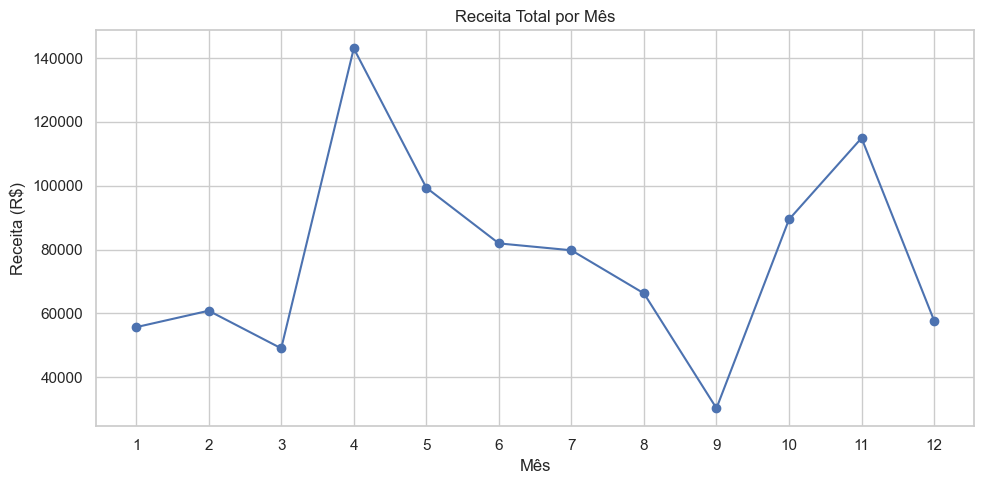

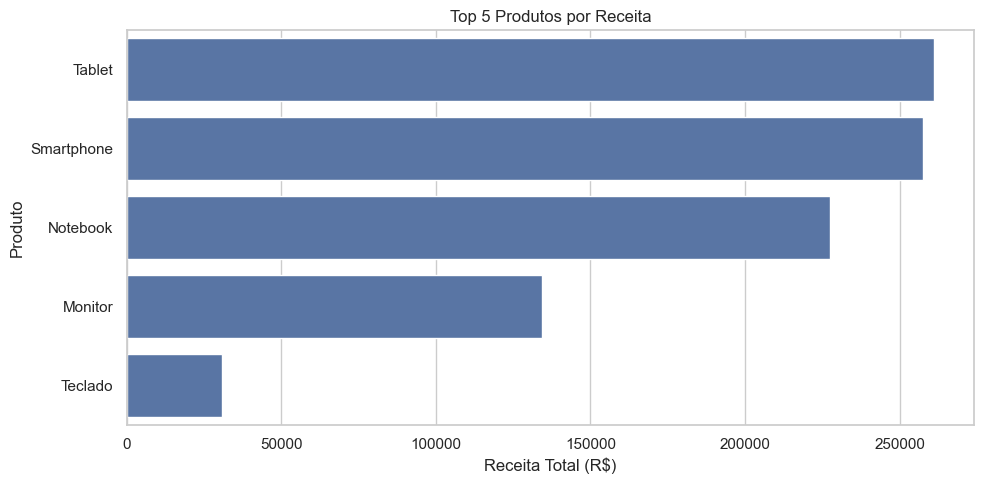

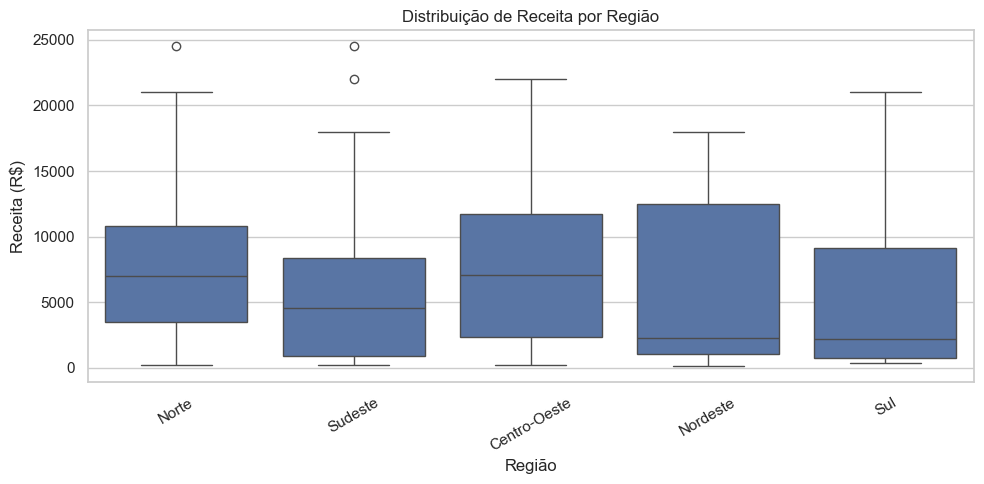

Gráficos salvos em: outputs/graficos


In [ ]:
gerar_visualizacoes(df, metricas)

No vídeo e README, você pode comentar:

gráfico de linha → tendência temporal
barras → ranking de produtos
boxplot → dispersão e outliers por região

RF10 – Organização do Código em Funções Reutilizáveis

Célula 39 – Função de limpeza (refatorada do RF03)

In [ ]:
def limpar_dados(df):
    """
    Limpa dados brutos:
    - remove espaços extras
    - converte datas
    - remove nulos críticos
    """

    import re
    df = df.copy()

    colunas_texto = df.select_dtypes(include=["object"]).columns

    for col in colunas_texto:
        df[col] = df[col].apply(
            lambda x: re.sub(r"\s+", " ", str(x)).strip()
            if pd.notna(x) else x
        )

    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")

    df = df.dropna(subset=["data_venda", "quantidade", "preco_unitario"])

    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    return df

Célula 40 – Função de colunas derivadas (RF05 reorganizado)

In [ ]:
def criar_colunas_derivadas(df):
    """
    Cria variáveis analíticas:
    receita_total, mes, trimestre, ano, faixa de receita
    """

    df = df.copy()

    # Receita total
    df["receita_total"] = df["quantidade"] * df["preco_unitario"]

    # Componentes de data
    df["mes"] = df["data_venda"].dt.month
    df["trimestre"] = df["data_venda"].dt.quarter
    df["ano"] = df["data_venda"].dt.year

    # Faixa de receita
    df["faixa_receita_item"] = np.select(
        [
            df["receita_total"] < 500,
            df["receita_total"] < 5000,
            df["receita_total"] >= 5000
        ],
        ["Baixo", "Médio", "Alto"],
        default="Baixo"
    )

    return df

Célula 41 – Função de métricas (RF06 reorganizado)

In [ ]:
def calcular_metricas(df):
    """
    Calcula métricas agregadas.
    """

    metricas = {}

    metricas["por_mes"] = (
        df.groupby("mes")
          .agg(
              receita_total=("receita_total", "sum"),
              quantidade=("quantidade", "sum")
          )
          .reset_index()
    )

    metricas["top_produtos"] = (
        df.groupby("produto")["receita_total"]
          .sum()
          .sort_values(ascending=False)
          .head(5)
          .reset_index()
    )

    metricas["por_categoria"] = (
        df.groupby("categoria")["receita_total"]
          .sum()
          .reset_index()
    )

    metricas["por_regiao"] = (
        df.groupby("regiao")["receita_total"]
          .sum()
          .reset_index()
    )

    return metricas

Célula 42 – Função de visualização (RF09 encapsulado)

In [ ]:
def gerar_visualizacoes(df, metricas):
    """
    Gera gráficos principais do projeto.
    """

    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_theme(style="whitegrid")

    # linha
    plt.figure()
    plt.plot(metricas["por_mes"]["mes"],
             metricas["por_mes"]["receita_total"])
    plt.title("Receita por mês")
    plt.show()

    # barras
    plt.figure()
    sns.barplot(
        data=metricas["top_produtos"],
        x="receita_total",
        y="produto"
    )
    plt.title("Top produtos")
    plt.show()

    # histograma
    plt.figure()
    sns.histplot(df["receita_total"], bins=20)
    plt.title("Distribuição da receita")
    plt.show()

Célula 43 – Função de ordem superior (lambda exigido)

In [ ]:
def aplicar_transformacao(df, coluna, funcao):
    """
    Aplica função (ou lambda) em uma coluna.
    """

    df = df.copy()

    df[f"{coluna}_transformado"] = df[coluna].apply(funcao)

    return df

Célula 44 – Pipeline final

/var/folders/r0/fxdqgfz904g5nln666tcc_vr0000gn/T/ipykernel_45899/2377076097.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df.select_dtypes(include=["object"]).columns


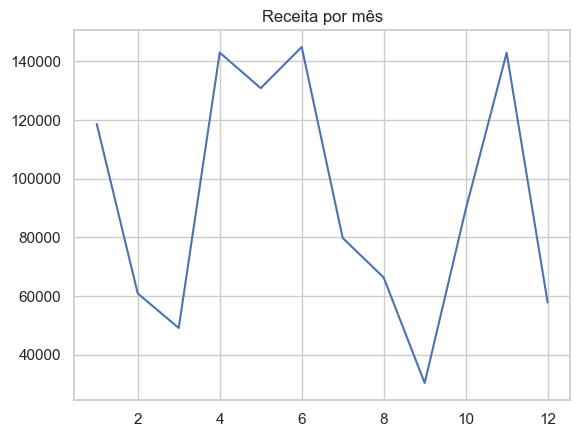

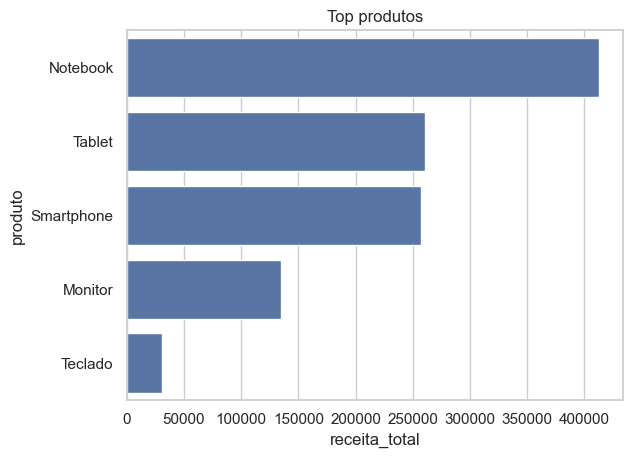

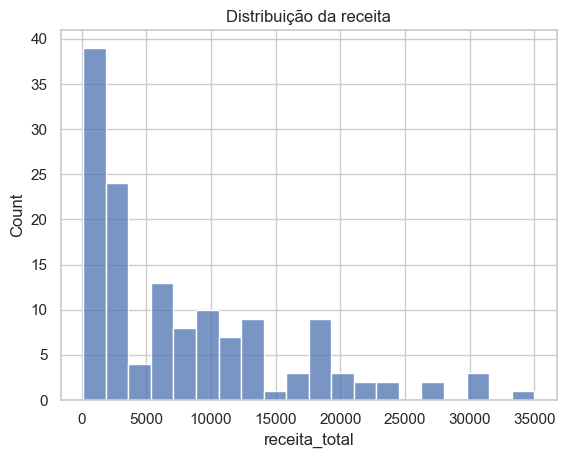

In [ ]:
df_limpo = limpar_dados(df_bruto)
df_final = criar_colunas_derivadas(df_limpo)
metricas = calcular_metricas(df_final)

gerar_visualizacoes(df_final, metricas)

RF11 – Exportação CSV e JSON (célula corrigida)

In [ ]:
import os
import json

def exportar_resultados(metricas, clientes, stats):
    """
    Exporta resultados da análise em CSV e JSON e valida leitura do JSON.
    """

    os.makedirs("outputs", exist_ok=True)

    # =========================
    # CSVs
    # =========================

    metricas["por_mes"].to_csv(
        "outputs/metricas_por_mes.csv",
        index=False,
        encoding="utf-8-sig"
    )
    print("CSV exportado: outputs/metricas_por_mes.csv")

    clientes.to_csv(
        "outputs/segmentacao_clientes.csv",
        index=False,
        encoding="utf-8-sig"
    )
    print("CSV exportado: outputs/segmentacao_clientes.csv")

    # =========================
    # JSON
    # =========================

    stats_serializaveis = {
        k: float(v) if isinstance(v, (int, float)) else v
        for k, v in stats.items()
    }

    caminho_json = "outputs/estatisticas_gerais.json"

    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(stats_serializaveis, f, indent=2, ensure_ascii=False)

    print(f"JSON exportado: {caminho_json}")

    # =========================
    # Leitura de validação
    # =========================

    with open(caminho_json, encoding="utf-8") as f:
        lido = json.load(f)

    print("\nJSON lido de volta (validação):")
    print(json.dumps(lido, indent=2, ensure_ascii=False))


# execução
exportar_resultados(metricas, clientes, stats)

CSV exportado: outputs/metricas_por_mes.csv
CSV exportado: outputs/segmentacao_clientes.csv
JSON exportado: outputs/estatisticas_gerais.json

JSON lido de volta (validação):
{
  "media": 6928.731343283582,
  "mediana": 5100.0,
  "desvio_padrao": 6449.662425696054,
  "min": 120.0,
  "max": 24500.0,
  "soma_total": 928450.0,
  "p25": 1200.0,
  "p75": 10800.0,
  "acima_da_media": 60.0
}


RF12 – Célula final consolidada

In [ ]:
import os

# ================================
# RF12 — CONSOLIDAÇÃO FINAL
# ================================

# Escolha da versão final do dataset
# Aqui você decide qual base será usada como "oficial"
# v1 = com outliers | v2 = outliers tratados
df_final = df_v2.copy()   # você pode trocar para df_v1 se quiser

# Criação da pasta final
os.makedirs("data/final", exist_ok=True)

# Salvamento do dataset final do projeto
df_final.to_csv("data/final/vendas_final.csv", index=False)

# Confirmação
print("=== RF12 CONCLUÍDO ===")
print("Dataset final salvo em: data/final/vendas_final.csv")
print(f"Shape final: {df_final.shape}")

# Verificação rápida
df_final.head()

=== RF12 CONCLUÍDO ===
Dataset final salvo em: data/final/vendas_final.csv
Shape final: (134, 8)


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6,1800.0
6,7,2024-05-28,Cliente_015,Notebook,Computadores,Nordeste,4,3500.0
7,8,2024-06-30,Cliente_020,Smartphone,Celulares,Sul,6,2200.0


In [ ]:
print(df_final.isnull().sum())
print(df_final.describe())

id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        0
preco_unitario    0
dtype: int64
         id_venda                  data_venda  quantidade  preco_unitario
count  134.000000                         134  134.000000      134.000000
mean    77.447761  2024-06-27 01:15:13.432835    5.276119     1446.940299
min      1.000000         2024-01-08 00:00:00    1.000000      120.000000
25%     41.250000         2024-04-08 00:00:00    3.000000      250.000000
50%     79.000000         2024-06-21 00:00:00    5.000000     1200.000000
75%    114.500000         2024-09-15 06:00:00    8.000000     2200.000000
max    150.000000         2024-12-27 00:00:00   10.000000     3500.000000
std     42.978324                         NaN    2.802769     1135.016960
